# Juzgando por la portada 

Este notebook pretende mostrar la implementación y funcionamiento del proyecto *Juzgando por la portada* de la asignatura de Procesamiento de Imágenes Digitales (PID) de la Universidad de Sevilla. 

## Pasos previos
Si pretendes ejecutar este notebook, se recomienda encarecidamente usar CUDA para poder habilitar el entrenamiento con la GPU.
CUDA tiene que estar instalado de antemano.

TODO: actualizar 

> NOTA: se recomienda encarecidamente usar Linux directamente debido a las conocidas complicaciones de usar CUDA en Windows. Si aun así el usuario quisiera seguir usando Windows, se anima al usuario a encontrar soluciones y/o vías alternativas en foros o guías por su propia cuenta. 

# Imports

En esta celda puedes encontrar TODOS los imports que vas a necesitar a lo largo del notebook, asegúrate de que esta celda corre correctamente para evitar problemas futuros en la ejecución del notebook.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import clear_output
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from lib import *

I0000 00:00:1778081133.591103     973 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778081134.944818     973 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778081138.016865     973 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



Verificando qué imágenes existen...
Total imágenes en CSV: 415966
Imágenes que existen: 404703
Imágenes faltantes: 11263

Datos después del filtrado:
Imágenes de entrenamiento: 323762
Imágenes de validación: 80941
Total usado para entrenar: 404703
Géneros (19): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Resolución de entrada: (192, 288)

Creando datasets optimizados para GPU...


I0000 00:00:1778081372.181169     973 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


OK: Datasets creados con map paralelo y prefetch


# Definición del modelo

Podemos observar que tenemos un modelo con 3 bloques, dos capas convolucionales con función de activación ReLU y MaxPooling, un tercer bloque con GAP y finalmente una última capa con función de activación sigmoide para tener una salida binaria multietiqueta. 

In [2]:
def intersperse(list, delimiter):
    try:
        it = iter(list)
        yield next(it)
        for x in it:
            yield delimiter
            yield x
    except StopIteration:
        return

def createModel(convLayers=3, firstConvFilterCount=32, denseLayers=1, firstDenseNeuronCount=256):
    model = models.Sequential(
        [
            layers.Input(shape=(*IMG_SIZE, 3)),
        ]
        +
        # Capas convolucionales
        list(intersperse(
            # Cada capa convolucional tiene el doble de filtros de la anterior
            [layers.Conv2D(firstConvFilterCount * (2 ** i), (3, 3), padding='same', activation='relu')
            for i in range(0,convLayers)],
            # Between each is a MaxPooling2D layer
            layers.MaxPooling2D(2, 2)
        ))
        +
        # GAP final para reducir dimensionalidad
        [
            layers.GlobalAveragePooling2D(),
        ]
        +
        [ 
            # Cada capa densa tiene la mitad de filtros de la anterior
            layers.Dense(int(firstDenseNeuronCount / (2 ** i)), activation='relu')
            for i in range(0,denseLayers)
        ]
        +
        # En mixed precision dejamos la salida en float32 para mayor estabilidad numérica (esto me lo ha dicho la IA¿?)
        [
            layers.Dense(len(genre_columns), activation='sigmoid', dtype='float32')
        ]
    )

    # Compilar el modelo
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    return model

# Busqueda en cuadrícula

Entrenando modelo con: 
 - Capas convolucionales: 2
 - Cantidad de filtros en la primera capa convolucional: 32
 - Capas densas: 1
 - Cantidad de neuronas en la primera capa densa: 256
Saltando conv2_filters32_dense1_neurons256 (ya entrenado)
Entrenando modelo con: 
 - Capas convolucionales: 2
 - Cantidad de filtros en la primera capa convolucional: 32
 - Capas densas: 1
 - Cantidad de neuronas en la primera capa densa: 512
Saltando conv2_filters32_dense1_neurons512 (ya entrenado)
Entrenando modelo con: 
 - Capas convolucionales: 2
 - Cantidad de filtros en la primera capa convolucional: 32
 - Capas densas: 2
 - Cantidad de neuronas en la primera capa densa: 256
Saltando conv2_filters32_dense2_neurons256 (ya entrenado)
Entrenando modelo con: 
 - Capas convolucionales: 2
 - Cantidad de filtros en la primera capa convolucional: 32
 - Capas densas: 2
 - Cantidad de neuronas en la primera capa densa: 512
Saltando conv2_filters32_dense2_neurons512 (ya entrenado)
Entrenando modelo con: 
 - C

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 192, 288, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 72, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 144, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 72, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 72, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,955 (1.80 MB)

 Trainable params: 471,955 (1.80 MB)

...

10118/10118 - 64s - 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.4009 - val_loss: 0.2210
Epoch 11/25
10118/10118 - 916s - 91ms/step - accuracy: 0.4064 - loss: 0.2192 - val_accuracy: 0.4088 - val_loss: 0.2189
Epoch 12/25


I0000 00:00:1778087272.892423    2314 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6939450995777923077
I0000 00:00:1778087272.892489    2314 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6294234818233499636


10118/10118 - 63s - 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.4088 - val_loss: 0.2189
Epoch 13/25
10118/10118 - 980s - 97ms/step - accuracy: 0.4141 - loss: 0.2171 - val_accuracy: 0.3965 - val_loss: 0.2213
Epoch 14/25


I0000 00:00:1778088315.511186    2314 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6939450995777923077
I0000 00:00:1778088315.511255    2314 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6294234818233499636


10118/10118 - 69s - 7ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3965 - val_loss: 0.2213
Entrenamiento completado
Epocas entrenadas: 14
Val loss final: 0.2213


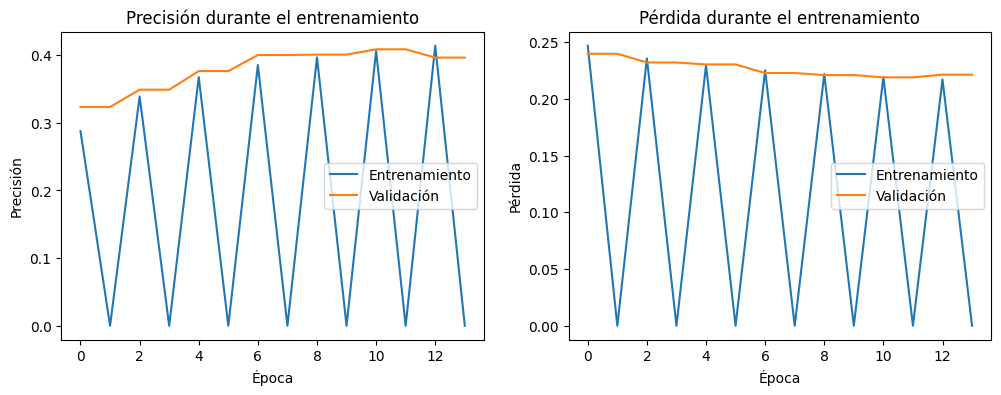

Etiquetas de validación usadas en evaluación: 80941
2530/2530 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step

=== RESULTADOS DE EVALUACION ===
Exact Match Ratio: 0.1446
Precision (Micro): 0.6181
Recall (Micro): 0.1723
F1 Score (Micro): 0.2695
Precision (Macro): 0.4954
Recall (Macro): 0.0824
F1 Score (Macro): 0.1216


E0000 00:00:1778088526.215197    2213 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


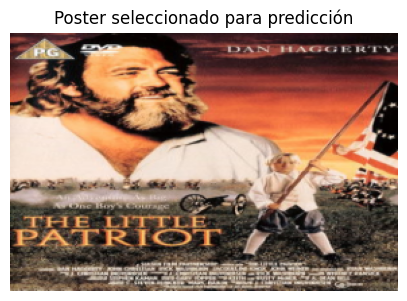

=== PREDICCION DEL MODELO ===
Imagen: ../imagenes/4N5VreatHj9ktVbml8WthCM6qb2.jpg
Géneros reales: ['Adventure', 'Family']
Géneros predichos (umbral=0.5): ['Drama']

Top-5 probabilidades:
  - Drama: 0.4330
  - Action: 0.2567
  - Horror: 0.1316
  - Thriller: 0.1311
  - Fantasy: 0.0946
Entrenando modelo con: 
 - Capas convolucionales: 3
 - Cantidad de filtros en la primera capa convolucional: 64
 - Capas densas: 2
 - Cantidad de neuronas en la primera capa densa: 512
Saltando conv3_filters64_dense2_neurons512 (ya entrenado)


In [3]:
RESULTS_DIR = "resultados_modelos"
os.makedirs(RESULTS_DIR, exist_ok=True)

def result_path(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount):
    return os.path.join(RESULTS_DIR, f"conv{convLayers}_filters{firstConvFilterCount}_dense{denseLayers}_neurons{firstDenseNeuronCount}")

def generate_text(hyperparams, metrics):
    text = ""

    text += "=== HIPERPARÁMETROS ===\n"

    for k, v in hyperparams.items():
        text += f"  {k}: {v}\n"

    text += "\n=== MÉTRICAS ===\n"
    for k, v in metrics.items():
        text += f"  {k}: {v:.4f}\n"

    return text


possibilities = [
    # Convolutional layers
    [2,3],
    # Filter count of first convolutional layer
    [32,64],
    # Dense layers
    [1,2],
    # Neuron count of first dense neuron
    [256,512]
]

permutations = list(itertools.product(*possibilities))

for [convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount] in permutations:
    print("Entrenando modelo con: ")
    print(f" - Capas convolucionales: {convLayers}")
    print(f" - Cantidad de filtros en la primera capa convolucional: {firstConvFilterCount}")
    print(f" - Capas densas: {denseLayers}")
    print(f" - Cantidad de neuronas en la primera capa densa: {firstDenseNeuronCount}")
    
    path = result_path(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount)

    if os.path.exists(path + ".keras"):
        print(f"Saltando {os.path.basename(path)} (ya entrenado)")
        continue

    model = createModel(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount)
    history = train_model(model)
    represent_data(history)
    [exact_match, precision_micro, recall_micro, f1_micro, precision_macro, recall_macro, f1_macro] = evaluate_model(model)
    predict_single_image(model)

    save_result(path,
        generate_text({
            "convLayers": convLayers,
            "firstConvFilterCount": firstConvFilterCount,
            "denseLayers": denseLayers,
            "firstDenseNeuronCount": firstDenseNeuronCount,
        },
        {
            "exact_match": exact_match,
            "precision_micro": precision_micro,
            "recall_micro": recall_micro,
            "f1_micro": f1_micro,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
        })
        ,model
    )
